Praktikum W05S03


=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


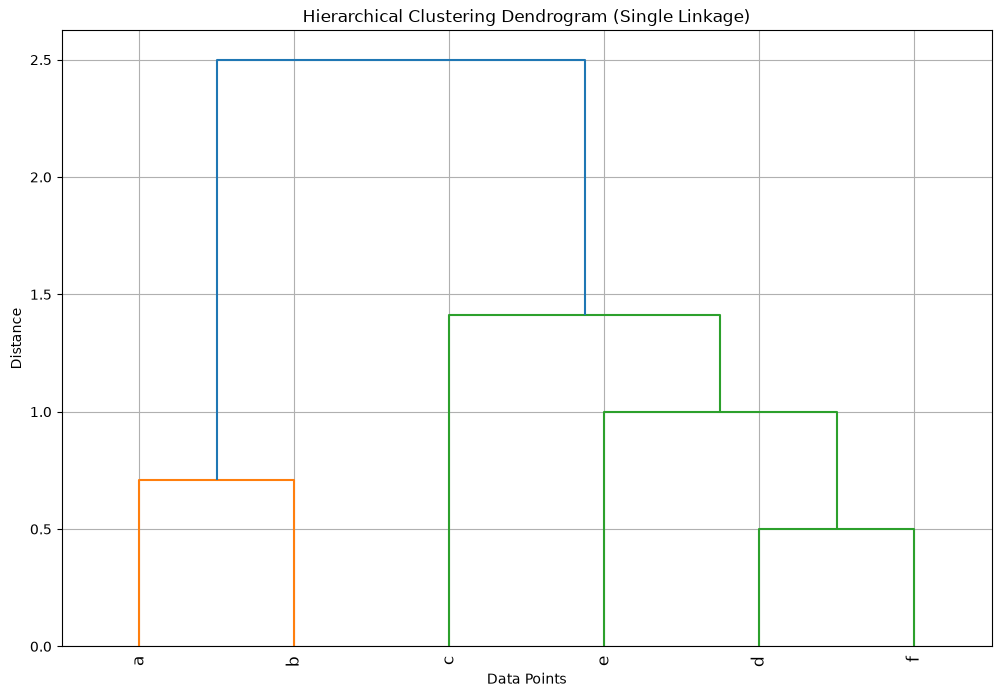

In [5]:

import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Pada bagian import numpy as np, import pandas as pd, from scipy.cluster.hierarchy import linkage, dendrogram, from scipy.spatial.distance import pdist, squareform, serta import matplotlib.pyplot as plt, kita memanggil semua perkakas yang dibutuhkan.

numpy dipakai untuk mengolah matriks angka, 
pandas untuk menampilkan tabel data yang rapi, 
scipy untuk menghitung jarak Euclidean sekaligus membuat diagram pohon, dan 
matplotlib untuk menggambar grafiknya ke layar.   

Bagian data = np.array([[1.0, 1.0], [1.5, 1.5], [5.0, 5.0], [3.0, 4.0], [4.0, 4.0], [3.0, 3.5]]) berfungsi mendaftarkan 6 titik koordinat dua dimensi yang diberi label titik a sampai f sebagai bahan eksperimen.   

Pada baris distance_matrix = pdist(data, metric='euclidean') dan distance_df = pd.DataFrame(squareform(distance_matrix), columns=['a','b','c','d','e','f'], index=['a','b','c','d','e','f']), program menghitung jarak lurus (Euclidean) antara tiap pasang titik, lalu mengubah hasilnya menjadi bentuk matriks tabel persilangan agar kita bisa melihat seberapa jauh jarak antara titik a ke b, a ke c, dan seterusnya secara jelas.   

Selanjutnya di perintah linked = linkage(data, method='single'), program mulai mengelompokkan titik-titik tersebut berdasarkan jarak terdekat yang sudah dihitung sebelumnya menggunakan aturan single linkage.   Terakhir pada bagian plt.figure(figsize=(12, 8)), plt.title(...), dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90), serta plt.show(), kode ini menyiapkan kanvas gambar berukuran 12 8, memberi judul grafik, lalu menggambar pohon silsilah pengelompokannya dengan posisi label titik diputar 90 agar mudah dibaca sebelum ditampilkan ke layar.

In [6]:

import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Pada baris df = pd.read_csv("Mall_Customers.csv") dan df.head(), program membaca berkas data pelanggan mall berbentuk CSV lalu menampilkan 5 baris data teratas untuk melihat kolom apa saja yang tersedia.

In [7]:
x  = df.iloc[:, [3, 4]].values


Di bagian X = df.iloc[:, [3, 4]].values, kita mengambil data dari kolom ke-3 dan ke-4 saja, yaitu kolom Annual Income (pendapatan tahunan) dan Spending Score (skor pengeluaran), karena kedua variabel inilah yang akan menjadi tolok ukur pengelompokan pelanggan

In [8]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape


(200, 2)

Selanjutnya pada from sklearn.preprocessing import StandardScaler, data_scaler = StandardScaler(), dan scaled_data = data_scaler.fit_transform(X), kita menyamakan skala angka pada kedua kolom tersebut terlebih dahulu agar nilai pendapatan yang ribuan tidak mendominasi perhitungan jarak dibandingkan nilai skor pengeluaran

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

Kemudian di perintah clustering = linkage(scaled_data, method="complete", metric="euclidean"), program menjalankan proses hierarchical clustering pada data yang sudah disetarakan skalanya menggunakan aturan complete linkage (melihat jarak terjauh antar kelompok)

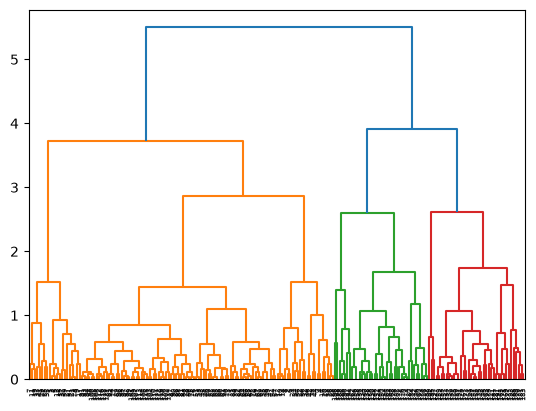

In [10]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()


Terakhir pada baris dendrogram(clustering) dan plt.show(), fungsi ini langsung menggambar pohon hierarki dari seluruh data pelanggan sehingga kita bisa melihat pembagian kelompok pelanggan (seperti kelompok pengeluaran rendah, sedang, dan tinggi) berdasarkan warna cabangnya

Tugas-W05S03


Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage
dan average linkage


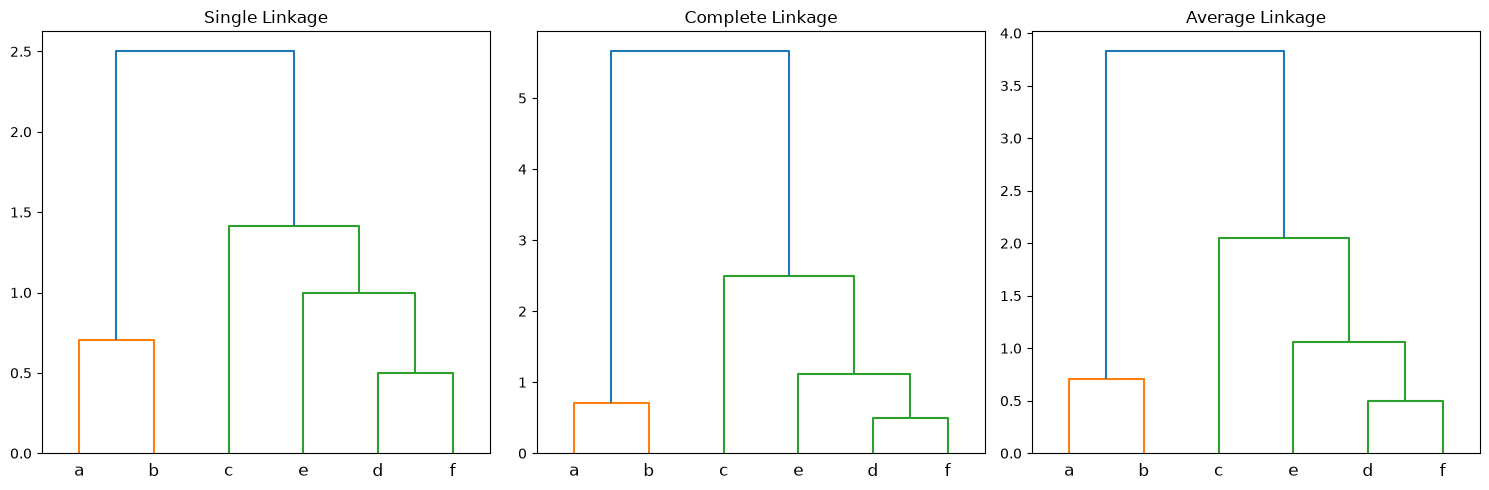

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

# Dataset sederhana dari percobaan 1
data = np.array(
    [
        [1.0, 1.0],  # a
        [1.5, 1.5],  # b
        [5.0, 5.0],  # c
        [3.0, 4.0],  # d
        [4.0, 4.0],  # e
        [3.0, 3.5],  # f
    ]
)

# Hitung linkage untuk ketiga metode
linked_single = linkage(data, method='single')
linked_complete = linkage(data, method='complete')
linked_average = linkage(data, method='average')

# Plot perbandingan dendrogram
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dendrogram(linked_single, labels=labels, ax=axes[0])
axes[0].set_title('Single Linkage')

dendrogram(linked_complete, labels=labels, ax=axes[1])
axes[1].set_title('Complete Linkage')

dendrogram(linked_average, labels=labels, ax=axes[2])
axes[2].set_title('Average Linkage')

plt.tight_layout()
plt.show()

Bagian pertama import matplotlib.pyplot as plt, import numpy as np, serta from scipy.cluster.hierarchy import dendrogram, linkage ini fungsinya untuk memanggil dan mengaktifkan perkakas atau library pendukung ke dalam program kita. numpy bertugas sebagai kalkulator utama yang mengolah angka-angka koordinat secara cepat, scipy menyediakan alat khusus untuk menghitung jarak sekaligus membentuk diagram pohon pengelompokannya, dan matplotlib berperan sebagai papan kanvas yang menggambar hasil grafik ke layar komputer.

Bagian berikutnya saat mendefinisikan data = np.array(...) digunakan untuk mendaftarkan titik-titik koordinat dua dimensi yang mau dikelompokkan, di mana angka di dalam tanda kurung siku mewakili posisi $X$ dan $Y$ dari masing-masing titik $a$ sampai $f$.

Selanjutnya pada baris linked_single = linkage(data, method='single'), linked_complete = linkage(data, method='complete'), dan linked_average = linkage(data, method='average'), program mulai menjalankan proses perhitungan jarak dan pengelompokan menggunakan tiga aturan yang berbeda. Aturan single mengukur jarak berdasarkan dua titik terdekat antar kelompok, aturan complete melihat dua titik terjauh, sedangkan aturan average menghitung nilai rata-rata jarak dari seluruh titik yang ada.

Kemudian perintah fig, axes = plt.subplots(1, 3, figsize=(15, 5)) dipakai untuk merancang area gambar agar kanvas utama dibagi menjadi tiga kotak bingkai berjejer ke samping dengan ukuran yang pas.

Setelah kanvas siap, baris dendrogram(linked_single, labels=labels, ax=axes[0]) beserta dua baris perintah dendrogram di bawahnya bertugas menggambar garis-garis bercabang menyerupai pohon di masing-masing bingkai kotak tersebut. Parameter ax=axes menentukan lokasi kotak mana yang akan digambar, sedangkan set_title dipakai untuk menempelkan judul nama metode di bagian atas tiap gambar.

Terakhir, perintah plt.tight_layout() dan plt.show() berfungsi untuk merapikan tata letak semua tulisan serta garis grafik agar tidak saling bertabrakan, lalu memunculkan hasil gambar analisis kelompok tersebut secara utuh ke layar monitor. Pastikan kamu sudah mendefinisikan variabel labels = ['a', 'b', 'c', 'd', 'e', 'f'] di awal agar nama tiap titik bisa langsung tercetak di bawah grafik.